In [1]:
import gymnasium as gym

# env = gym.make("LunarLander-v3", render_mode="human")
# observation, info = env.reset(seed=67)
# for _ in range(10):
#     action = env.action_space.sample()
#     observation, reward, terminated, truncated, info = env.step(action)
#     if terminated or truncated:
#         observation, info = env.reset()
# env.close()
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

from IPython.display import clear_output
from time import sleep
from tqdm import tqdm

In [2]:
class Racetrack:
    def __init__(self):
        self.track = np.empty((40,15), dtype=np.str_)
        self.track[:] = "|"
        self.track[:30, 10:] = '-'
        self.track[30:, -1] = 'F'
        # set random starting position
        self.carv = 0 
        self.carh = np.random.choice(range(9))
        self.velo_vert = 0
        self.velo_hori = 0
        self.track[self.carv, self.carh] = 'C'
        self.crashed = False
        self.at_end = False
    
    def print_state(self):
        for i in reversed(range(self.track.shape[0])):
            print(str(self.track[i, :]))
    
    def step(self, action):
        old_v = self.carv
        old_h = self.carh
        # update car velocity 
        vert, hori = action

        self.velo_vert += vert
        self.velo_hori += hori

        if self.velo_vert <= 0:
            self.velo_vert = 1

        if self.velo_vert > 5:
            self.velo_vert = 5
        if self.velo_hori > 5:
            self.velo_hori = 5

        self.carv += self.velo_vert
        self.carh += self.velo_hori

        # reward = distance between previous and current state
        reward = np.sqrt((self.carv-old_v)**2 + (self.carh-old_v)**2)
        # check if dead, if dead reward = 0
        # check if end if end reward is 5 and end
        self.spot_check(self.carv, self.carh)
         
        if self.at_end:
            reward = 5
        elif self.crashed:
            reward = 0
        else:
            self.track[self.carv, self.carh] = 'C'
        return reward 

    def spot_check(self, v, h):
        # checks if the entering spot is a crash
        if (v >= 40 or v < 0):
            self.crashed = True
            self.at_end = False
        elif (h >= 15 or h < 0):
            self.crashed = True
            self.at_end = False
        elif self.track[v,h] == '-':
            self.crashed = True
            self.at_end = False
        elif self.track[v,h] == 'F':
            self.crashed = False
            self.at_end = True
    
    def reset(self):
        # resets to start 
        self.track[:] = "|"
        self.track[:30, 10:] = '-'
        self.track[30:, -1] = 'F'
        # set random starting position
        self.carv = 0 
        self.carh = np.random.choice(range(9))
        self.velo_vert = 0
        self.velo_hori = 0
        self.track[self.carv, self.carh] = 'C'
        self.crashed = False
        self.at_end = False

def get_action():
    vert = np.random.choice([-1,0,1])
    hori = np.random.choice([-1, 0,1])
    return (vert, hori)

v, h = get_action()
v,h

(np.int64(1), np.int64(-1))

In [6]:
data = {
    't':[],
    'cum_reward':[],
    'finish':[],
    'crash':[]
}
cum_heat = np.zeros((40,15))
fin_heat = np.zeros((40,15))
crash_heat = np.zeros((40,15))
track = Racetrack()
for i in tqdm(range(15000)):
    cum_reward = 0
    t = 0 
    while (not track.crashed or track.at_end):
        t+=1
        v, h = get_action()
        cum_reward += track.step((v,h))
        # print("t: ",t ,"Cum Reward: ", cum_reward, "\nCrashed: ", track.crashed, "\nAt End: ", track.at_end)       
        clear_output(wait=True)
    cum_heat += np.where(track.track == 'C', 1, 0)
    if track.at_end:
        fin_heat += np.where(track.track == 'C', 1, 0)
        data['finish'].append(1)
        data['crash'].append(0)
    elif track.crashed:
        crash_heat += np.where(track.track == 'C', 1, 0)
        data['finish'].append(0)
        data['crash'].append(1)
    data['t'].append(t)
    data['cum_reward'].append(cum_reward)
    track.reset()


100%|██████████| 15000/15000 [00:42<00:00, 353.70it/s]


In [7]:
df = pd.DataFrame(data=data)
df['finish'].sum()

np.int64(0)

<Axes: >

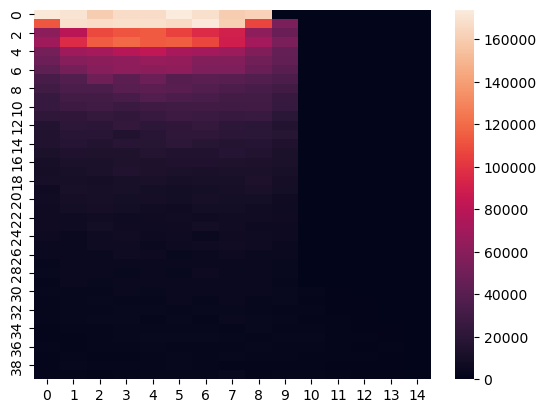

In [11]:
sns.heatmap(data=cum_heat*100)

<Axes: >

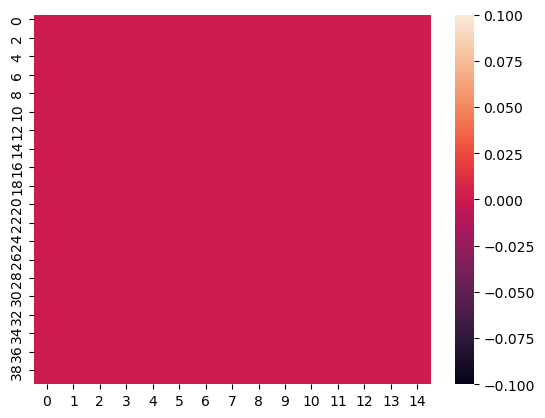

In [9]:
sns.heatmap(data=fin_heat)

<Axes: >

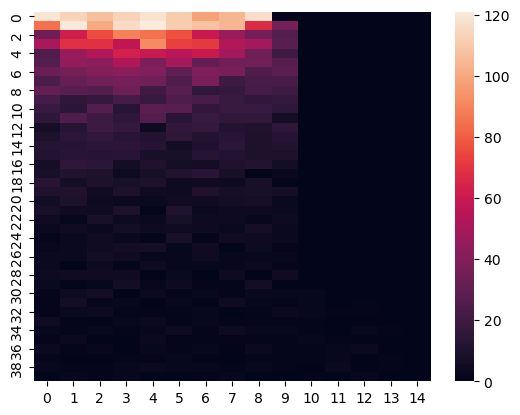

In [7]:
sns.heatmap(data=crash_heat)

In [238]:
df['finish'].sum()

np.int64(0)

In [13]:
track.print_state()

['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '|' 'F']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|' '|' '|' '|' '|' '|' '|' '|' '|' '-' '-' '-' '-' '-']
['|' '|'